  Fiscal_Year  [A]Agriculture forestry and fishing  [B]Mining and quarrying  \
0     2011/12                               699905                    12722   
1     2012/13                               735270                    13470   
2     2013/14                               805271                    15420   
3     2014/15                               846567                    16249   
4     2015/16                               879071                    17314   

   [C]Manufacturing  [D]Electricity and gas  \
0            416291                   36116   
1            457168                   44713   
2            515077                   49357   
3            539998                   51540   
4            535031                   53883   

   [E]Water supply]sewerage and waste management  [F]Construction  \
0                                          21443           276247   
1                                          23777           295873   
2                                  

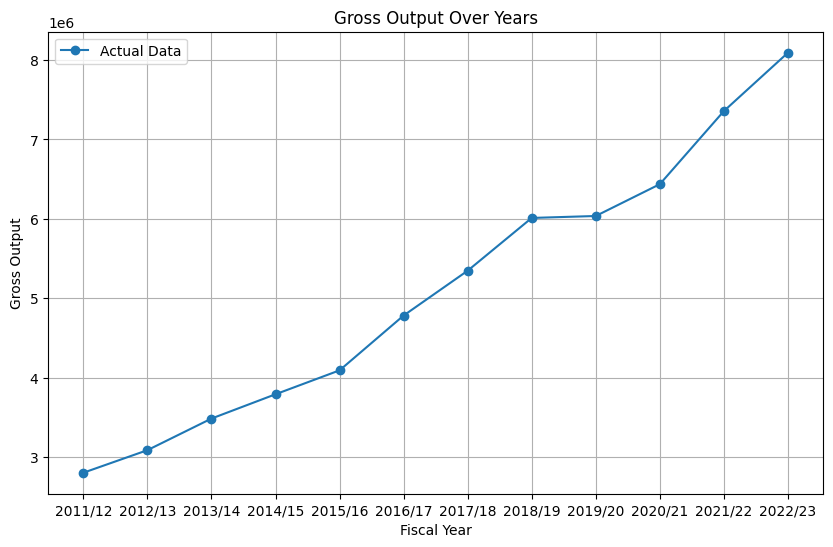

Linear Regression from Scratch - MSE: 119683622274.44392, R2: 0.9689907321566428
Model - 1 (Scikit-Learn Linear Regression) - MSE: 119683622259.64821, R2: 0.9689907321604763
Model - 2 (Polynomial Regression) - MSE: 66601056661.288414, R2: 0.9827440884106539


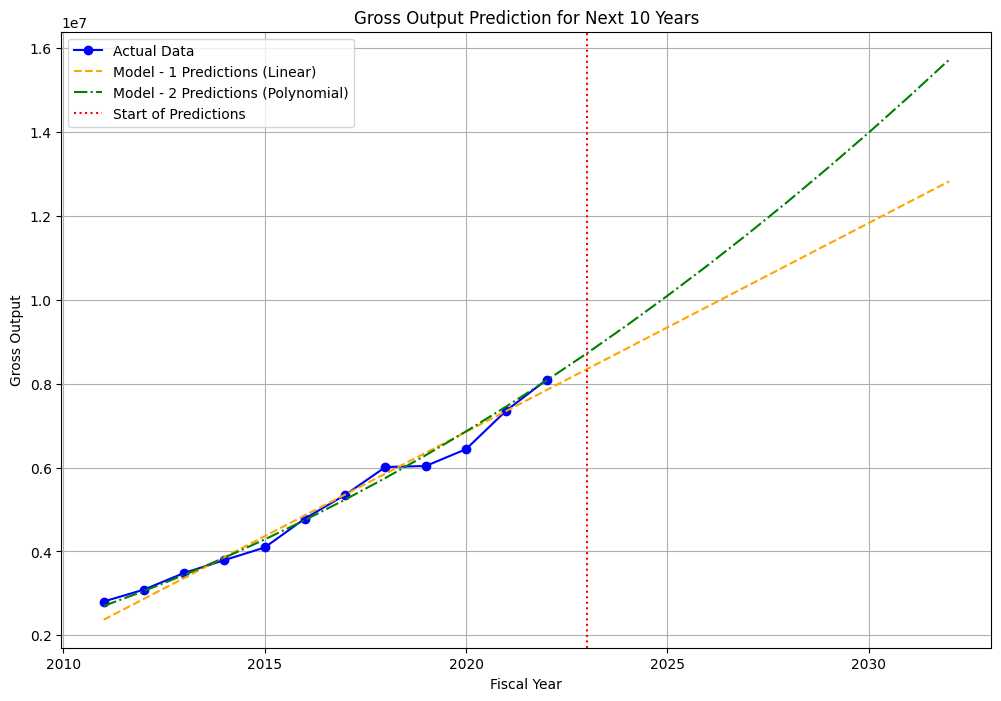

Results Summary:
Model - 1 (Linear Regression) performed better with R2: 0.9689907321604763 compared to Model - 2 (Polynomial Regression) with R2: 0.9827440884106539.


In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression

# Load the dataset
data = pd.read_csv("/content/cleaned_gross_output.csv")

# Display the dataset
print(data.head())

# ❑ Approval for the Dataset and Project.
# Assuming the dataset is approved for use.

# ❑ Exploratory Data Analysis (EDA)
# Statistical Interpretation and Visualizations
print(data.describe())
print(data.info())

# Plot the trend of Gross Output over the years
plt.figure(figsize=(10, 6))
plt.plot(data['Fiscal_Year'], data['Gross Output at basic prices'], marker='o', label='Actual Data')
plt.title('Gross Output Over Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Gross Output')
plt.legend()
plt.grid()
plt.show()

# ❑ Build Linear Regression from Scratch
class LinearRegressionFromScratch:
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add bias term
        theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.weights = theta_best[1:]
        self.bias = theta_best[0]

    def predict(self, X):
        X = np.array(X)
        return X.dot(self.weights) + self.bias

# Prepare the data for modeling
X = data['Fiscal_Year'].str.split('/').str[0].astype(int).values.reshape(-1, 1)  # Extract year as numeric
y = data['Gross Output at basic prices'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model from scratch
model_scratch = LinearRegressionFromScratch()
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)

# Evaluate the model
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)
print(f"Linear Regression from Scratch - MSE: {mse_scratch}, R2: {r2_scratch}")

# ❑ Build Two Models for Regression
# Model - 1: Linear Regression from Scikit-Learn
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

# Evaluate Model - 1
mse_1 = mean_squared_error(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred_1)
print(f"Model - 1 (Scikit-Learn Linear Regression) - MSE: {mse_1}, R2: {r2_1}")

# Model - 2: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_2 = LinearRegression()
model_2.fit(X_poly_train, y_train)
y_pred_2 = model_2.predict(X_poly_test)

# Evaluate Model - 2
mse_2 = mean_squared_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)
print(f"Model - 2 (Polynomial Regression) - MSE: {mse_2}, R2: {r2_2}")

# ❑ Generate Future Trends for 10 Years
future_years = np.array(range(2023, 2033)).reshape(-1, 1)
future_years_poly = poly.transform(future_years)

# Predictions for Model - 1
future_predictions_1 = model_1.predict(future_years)

# Predictions for Model - 2
future_predictions_2 = model_2.predict(future_years_poly)

# Combine actual data with future predictions
all_years = np.concatenate([X.flatten(), future_years.flatten()])
actual_data = np.concatenate([data['Gross Output at basic prices'].values, np.full(10, np.nan)])  # Fill future years with NaN for actual data
predictions_1 = np.concatenate([model_1.predict(X), future_predictions_1])
predictions_2 = np.concatenate([model_2.predict(poly.transform(X)), future_predictions_2])

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(all_years, actual_data, marker='o', label='Actual Data', color='blue')
plt.plot(all_years, predictions_1, label='Model - 1 Predictions (Linear)', linestyle='--', color='orange')
plt.plot(all_years, predictions_2, label='Model - 2 Predictions (Polynomial)', linestyle='-.', color='green')
plt.title('Gross Output Prediction for Next 10 Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Gross Output')
plt.axvline(x=2023, color='red', linestyle=':', label='Start of Predictions')  # Mark the start of predictions
plt.legend()
plt.grid()
plt.show()

# ❑ Results Summary
print("Results Summary:")
print(f"Model - 1 (Linear Regression) performed better with R2: {r2_1} compared to Model - 2 (Polynomial Regression) with R2: {r2_2}.")

In [1]:
from google.colab import files


uploaded = files.upload()

Saving cleaned_gross_output.csv to cleaned_gross_output.csv
